In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.Message,df.Category,test_size=0.2,random_state=10)

In [32]:
X_train[:2]

5281               And how you will do that, princess? :)
1300    Great to hear you are settling well. So what's...
Name: Message, dtype: object

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
v=CountVectorizer()

In [38]:
X_train_count=v.fit_transform(X_train)
X_test_count=v.transform(X_test)

In [39]:
X_train_count.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4457, 7723))

In [41]:
from sklearn.naive_bayes import MultinomialNB, GaussianNB
model=MultinomialNB()
model.fit(X_train_count,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [44]:
y_pred=model.predict(X_test_count)

### Model Evaluation:Precision,Recall,F!_Score


In [46]:
from sklearn.metrics import classification_report
cm=classification_report(y_test,y_pred)
print(cm)

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       972
        spam       0.96      0.90      0.93       143

    accuracy                           0.98      1115
   macro avg       0.97      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



# Model Evaluation:Confusion Matrix

In [47]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[967   5]
 [ 14 129]]


In [57]:
import seaborn as sns
from matplotlib import pyplot as plt

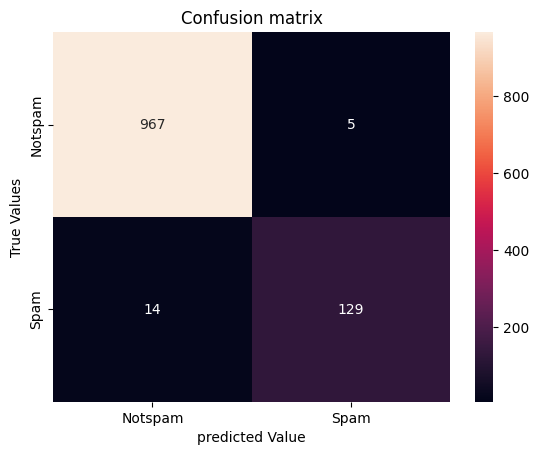

In [59]:
sns.heatmap(cm,annot=True,fmt='d',xticklabels=["Notspam","Spam"],yticklabels=["Notspam","Spam"])
plt.xlabel("predicted Value")
plt.ylabel("True Values")
plt.title("Confusion matrix")
plt.show()

In [60]:
email=[
    "You have been selected for a cash prize of ₹50,000. Call now to claim.",
    "Hey, are we still meeting for lunch at 1 PM?"
]
email_count=v.transform(email)

In [63]:
model.predict(email_count)

array(['spam', 'ham'], dtype='<U4')